# Julia notebook to compute the buoyancy field using the 1D vertical diffusion equation, inspired by Peterson & Callies (2025, in review) theory. Then compute the associated geostrophic flow using the frictional thermal wind equation.

twnh Sep '25

This notebook solves the steady vertical diffusion problem with a Green's function.

The problem is to solve:
\begin{align}
\kappa \frac{d^2 b}{dz^2} 
    + \gamma \left( B(z) - b \right) & = 0 , 
\end{align}
for $b(z)$, given buoyancy profile $B(z)$, relaxation coefficient $\gamma$, with boundary conditions
\begin{align}
 \frac{db}{dz}  &= 0 \text{~ at~} z = -H , \\
 b &= 0 \text{~ at~} z = 0 ,
\end{align}
where bottom buoyancy gradient is $\beta$ (can be zero).
This is the canonical form of Zwillinger (1992), page 270, if $\beta = 0$.

This problem is solved repeatedly for different $H(x)$ fields and $B(x,z)$ fields. This constructs a buoyancy field that varies in $(x,z)$ using the 1D diffusion equation.

Then, given $b(x,z)$, solve:

\begin{align}
- f \frac{d v}{d z} & = - \frac{\partial b}{\partial x} + \epsilon^2   \nu \frac{d^2 u}{d z^2}, \\
  f \frac{d u}{d z} & = - \frac{\partial b}{\partial y} + \epsilon^2   \nu \frac{d^2 v}{d z^2} , 
\end{align}
for $u(z), v(z)$, given viscosity $\nu$, and boundary conditions
\begin{align}
\text{Surface~}z = 0:
\begin{cases}
\displaystyle \epsilon^2 \nu \partial_z u & = \tau^x \\
\displaystyle  \epsilon^2 \nu \partial_z v & = \tau^y 
\end{cases}
 \\
\text{Bottom~}z = -H:
\begin{cases}
u & = 0  \\
v & = 0 
\end{cases} ,
\end{align}
where $(\tau^x, \tau^y)$ is the known wind stress.


See also: ``FindBuoyancyField.ipynb`` for the G's function solution to the 1D buoyancy equation, and ``FrictionalThermalWindSolution.ipynb`` for the G's function solution to the frictional thermal wind equation.

In [1]:
using SymPy

Define symbols and functions

In [ ]:
# Geometry symbolic parameters:
z, ξ   = symbols("z ξ",   real=true, negative=true) # Vertical coordinate and source location (both in [-H,0])
x      = symbols("x",     real=true)                # Horizontal coordinate
α      = 0.5                                        # Aspect ratio value
H      = α * (1 - x^2)                              # Bathymetry function
geometry_params = (H, z, ξ, α, x)

# Frictional thermal wind equation symbolic parameters:
f, ϵ   = symbols("f ϵ",   real=true, positive=true) # Coriolis parameter and Ekman number
ν₀, αν = symbols("ν₀ αν", real=true, positive=true) # Viscosity parameters
τˣ, τʸ = symbols("τˣ τʸ", real=true)                # Surface wind stress components

# Define viscosity profile here:
ν = ν₀                                              # Constant viscosity profile
# ν = ν₀ + exp(-αν*(z+H))                           # Bottom-intensified viscosity profile
# ν = ν₀ + exp(αν*z)                                # Surface-intensified viscosity profile

𝔲_params = (f, ϵ, ν, τˣ, τʸ)

# Buoyancy equation symbolic parameters:
κ₀, ακ = symbols("κ₀ ακ", real=true, positive=true) # Diffusivity parameters
γ      = symbols("γ",     real=true, positive=true) # Relaxation parameter
β      = symbols("β",     real=true)                # Bottom buoyancy gradient
β = 0                                               # Zero bottom buoyancy gradient. NON-ZERO β DOESN"T WORK YET!  I need to think about the math more carefully.
B      = SymFunction("B")                           # Source term function B(z): buoyancy field relaxation profile.

# Define diffusivity profile here:
κ = κ₀                                              # Constant viscosity profile
# κ = κ₀ + exp(-ακ*(z+H))                           # Bottom-intensified viscosity profile. THIS DOESN"T WORK YET!  SymPy struggles to compute the integrals at the end.

# Define the $B(z)$ source term here:
B = z                                               # Linear profile with vanishing surface buoyancy

b_params = (κ, γ, β, B) ;

### Set the problem parameters here:

In [3]:
f_val  = 1.0
ϵ_val  = 1.0

γ_val  = 1.0

ακ_val = 0.0
κ₀_val = 0.125

αν_val = 0.0
ν₀_val = κ₀_val

τˣ_val = 0.0
τʸ_val = 0.0
param_values = Dict(f=>f_val, ϵ=>ϵ_val, γ=>γ_val, ακ=>ακ_val, κ₀=>κ₀_val, αν=>αν_val, ν₀=>ν₀_val, τˣ=>τˣ_val, τʸ=>τʸ_val)

Dict{Sym{PyCall.PyObject}, Float64} with 9 entries:
  αν => 0.0
  τʸ => 0.0
  ν₀ => 0.125
  τˣ => 0.0
  κ₀ => 0.125
  ϵ  => 1.0
  ακ => 0.0
  f  => 1.0
  γ  => 1.0

Code to solve the buoyancy equation using a Green's function:

In [4]:
function compute_b_Gb(b_params, geometry_params, param_values)
    # Setup symbols and parameters:
    κ, γ, β, B    = b_params
    H, z, ξ, α, x = geometry_params
    b             = SymFunction("b")
    A             = symbols("A",     real=true)                      # Unknown coefficient in the Green's function solution
    im            = SymPy.im  # SymPy's imaginary unit
    
    #0. Define the ODE for b(z):
    ode = Eq(κ * diff(diff(b(z),z),z) - diff(κ,z) * diff(b(z),z) - γ * b(z), 0)

    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    bm = dsolve(ode, b(z), ics = Dict(diff(b(z),z).subs(z,-H)=>β)).rhs
    @assert simplify(diff(bm,z).subs(z,-H) - β) == 0              # Check Neumann BC at bottom
    bm_const = filter(x -> startswith(string(x), "C"), bm.free_symbols)
    bm = bm.subs(first(bm_const), A)                              # Replace constant with A so it doesn't conflict later

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    bp = dsolve(ode, b(z), ics = Dict(b(0)=>0) ).rhs
    @assert simplify(bp.subs(z,0)) == 0                           # Check Dirichlet BC at top
    # display(bp)

    # 3. Compute Wronskian $W(z)$:
    W = simplify(bm * diff(bp, z) - bp * diff(bm, z))

    # 4. Compute Green's function $G(z; \xi)$:
    Gm = simplify(bm * bp.subs(z,ξ) / (κ.subs(z,ξ) * W.subs(z,ξ)))
    Gp = simplify(bm.subs(z,ξ) * bp / (κ.subs(z,ξ) * W.subs(z,ξ)))

    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/κ.subs(z,ξ) == 0

    # display(Gm)
    # display(Gp)

    # Define piecewise Green's function:
    G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))

    # Check boundary conditions are satisfied
    @assert simplify(diff(G,z).subs(z,-H).subs(ξ,-H/3).subs(x,0) - β).subs(param_values) == 0
    @assert simplify(G.subs(z,0).subs(ξ,-H/3)) == 0

    # display(G)

    # 5. Solve the original problem using $G(z; \xi)$:
    G_subs = G.subs(param_values)
    b = simplify(integrate(-G_subs * γ * B.subs(z,ξ), (ξ,-H,0) ))
    # display(b)

    return b, G_subs
end

compute_b_Gb (generic function with 1 method)

Code to solve the frictional thermal wind equation using a Green's function:

In [5]:
function compute_𝔲_G𝔲(𝔲_params, geometry_params, param_values)
    # Setup symbols and parameters:
    f, ϵ, ν, τˣ, τʸ = 𝔲_params
    H, z, ξ, α, x   = geometry_params
    𝔲               = SymFunction("𝔲")
    im              = SymPy.im  # SymPy's imaginary unit

    #0. Define the ODE for 𝔲(z):
    ode = Eq(f * diff(𝔲(z),z) + ϵ^2 * im * diff(ν * diff(𝔲(z),z),z), 0)

    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    Gₘ = dsolve(ode, 𝔲(z), ics = Dict(𝔲(-H)=>0)).rhs
    @assert simplify(Gₘ.subs(z,-H)) == 0  # Check bottom BC

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    Gₚ = dsolve(ode, 𝔲(z), ics = Dict(diff(𝔲(z),z).subs(z,0)=>0)).rhs
    @assert simplify(diff(Gₚ,z).subs(z,0)) == 0  # Check surface BC
    # display(Gₚ)
    
    # 3. Compute Wronskian $W(z)$:
    W = simplify(Gₘ * diff(Gₚ, z) - Gₚ * diff(Gₘ, z))
    
    # 4. Compute Green's function $G(z; \xi)$:
    Gm = simplify(Gₘ * Gₚ.subs(z,ξ) / (W.subs(z,ξ)))
    Gp = simplify(Gₘ.subs(z,ξ) * Gₚ / (W.subs(z,ξ)))

    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1 == 0

    # Define piecewise Green's function:
    G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))
    # display(G)

    # Check boundary conditions:
    @assert simplify(G.subs([(z,-H),(ξ,-H/2)]).subs(x,-0.5).subs(ϵ,5).subs(αν,4).subs(ν₀,2).subs(f,3)) == 0
    @assert simplify(diff(G,z).subs(z,0).subs(ξ,-H/2)) == 0

    G_num = G.subs(param_values)
    
    return G_num
end

compute_𝔲_G𝔲 (generic function with 1 method)

# Compute the G's functions:

In [6]:
b, Gb = compute_b_Gb(b_params,geometry_params,param_values) 
G𝔲 = compute_𝔲_G𝔲(𝔲_params,geometry_params,param_values) ;

# Make plot of Green's functions for sample parameters

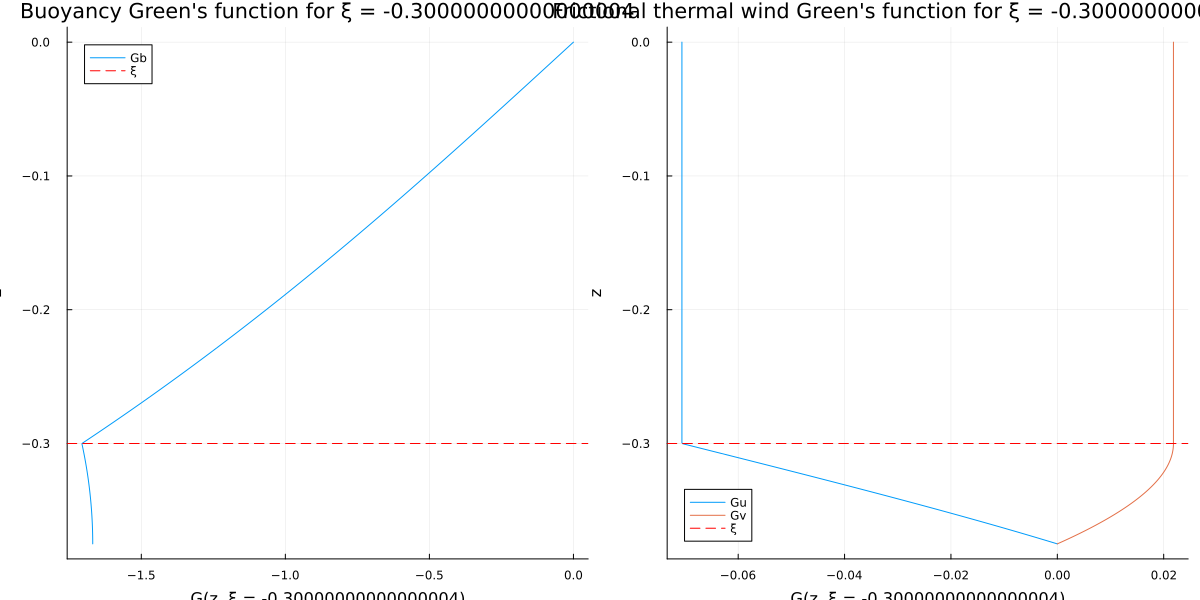

In [7]:
using Plots

this_x = -0.5
this_H = float(H(this_x))
this_ξ = -this_H * 0.8           # Pick the value of ξ in [-H, 0]:

# Insert parameter values here and convert symbolic the G's functions to a Julia function:
Gb_fixed(zᵢ,this_ξ) = Gb.subs([(ξ, this_ξ), (z, zᵢ), (x, this_x)])
G𝔲_fixed(zᵢ,this_ξ) = G𝔲.subs([(ξ, this_ξ), (z, zᵢ), (x, this_x)])

# --- Plot ---
zvals = range(-this_H, 0, length=512)
Gbvals = [Gb_fixed(z_, this_ξ) |> float   for z_ in zvals]  # use float() to get a number
G𝔲vals = [G𝔲_fixed(z_, this_ξ) |> complex for z_ in zvals]  # use complex() to get a number
plt1 = plot(Gbvals, zvals, label="Gb",ylabel="z", xlabel="G(z, ξ = $this_ξ)", title="Buoyancy Green's function for ξ = $this_ξ", legend=true)
hline!([this_ξ], label="ξ", linestyle=:dash, color=:red)

plt2 = plot( real(G𝔲vals), zvals,label="Gu",ylabel="z", xlabel="G(z, ξ = $this_ξ)", title="Frictional thermal wind Green's function for ξ = $this_ξ", legend=true)
plot!(imag(G𝔲vals), zvals, label="Gv")
hline!([this_ξ], label="ξ", linestyle=:dash, color=:red)

plot(plt1, plt2, layout=(1,2), size=(1200,600))

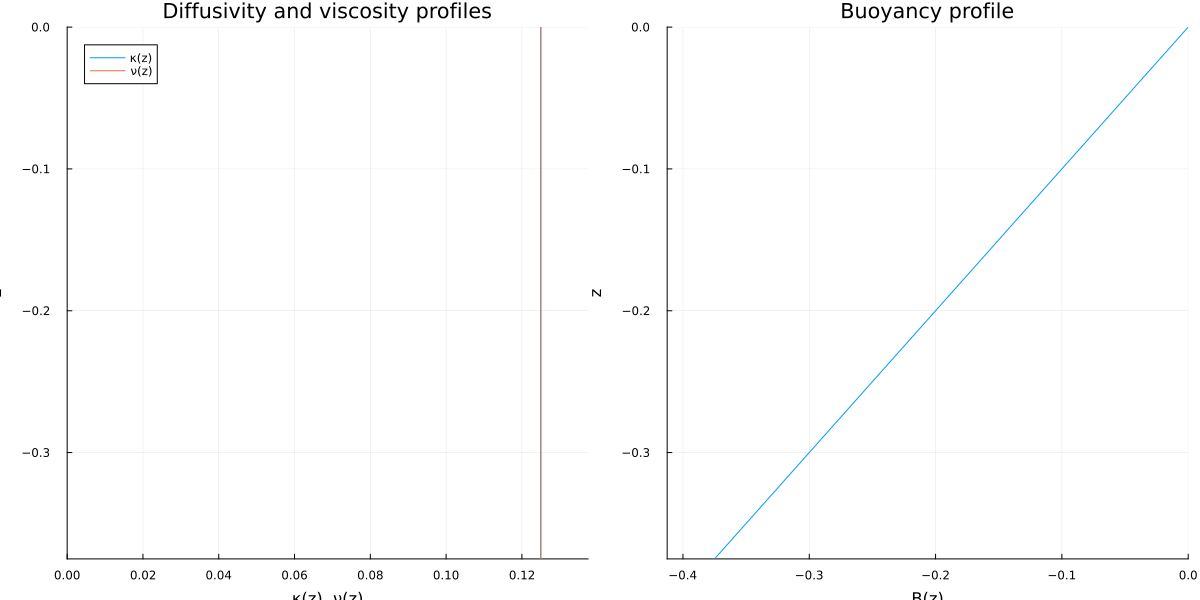

In [8]:
κ_fixed(zᵢ) = κ.subs(param_values).subs([(H, this_H), (z, zᵢ)])
ν_fixed(zᵢ) = ν.subs(param_values).subs([(H, this_H), (z, zᵢ)])
κvals = [κ_fixed(z_) |> float for z_ in zvals]
νvals = [ν_fixed(z_) |> float for z_ in zvals]
plt1 = plot(  κvals, zvals, label="κ(z)", ylabel="z", xlabel="κ(z), ν(z)", title="Diffusivity and viscosity profiles", xlims=(0,maximum(vcat(κvals,νvals)) * 1.1), ylims=(-this_H,0) )
plot!( νvals, zvals, label="ν(z)")

B_fixed(zᵢ) = B.subs([(z, zᵢ)])
Bvals = [B_fixed(z_) |> float for z_ in zvals]
plt2 = plot( Bvals, zvals, label="B(z)", ylabel="z", xlabel="B(z)", title="Buoyancy profile", legend=false, xlims=(minimum(Bvals) * 1.1,maximum(Bvals) * 1.1), ylims=(-this_H,0.0))

plot(plt1, plt2, layout=(1,2), size=(1200,600))

Loop over different depths to construct the buoyancy field $b(x,z)$

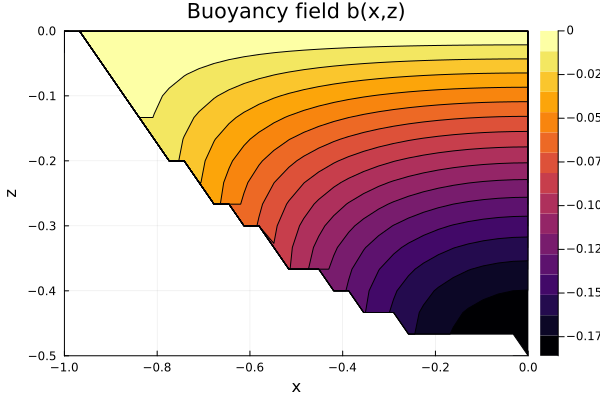

In [9]:
N = 16
xvals = collect(range(-1, 0, length=2*N))
zvals = float(collect(range(-maximum(H.(collect(xvals))), 0, length=N)))
H_vals = float(H.(collect(xvals)))
b_num = b.subs(param_values)        # Temporary symbolic b(z) with parameters inserted, but H still symbolic
bz = fill(NaN, length(zvals), length(xvals))

for (x_ind, this_x) ∈ enumerate(xvals)
    local this_H = H_vals[x_ind]
    this_b = b_num.subs(x,this_x)
    @assert simplify(diff(this_b,z).subs(z,-this_H) - β) < 1e-12        # Check Neumann BC at bottom
    @assert simplify(this_b.subs(z,0)) < 1e-12                          # Check Dirichlet BC at top    
    b_fixed(zᵢ) = this_b.subs(z, zᵢ)
    these_z_inds = findall(zvals .>= -this_H)                           # Only compute down to the local depth
    these_z_vals = zvals[these_z_inds]
    bvals = [b_fixed(z_) |> float for z_ in these_z_vals]
    bz[these_z_inds, findfirst(==(this_x), xvals)] = bvals              # Store b(x,z)
end
plt = contour(xvals, zvals, bz, xlabel="x", ylabel="z", title="Buoyancy field b(x,z)", fill=true)
display(plt)

Loop over different $(x,z)$ to construct the velocity field $v(x,z)$. Integrate numerically for the final answer. This double loop over $(x,z)$ is slow.

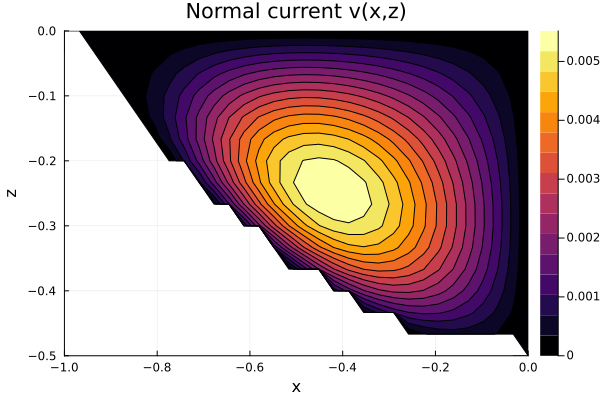

In [10]:
using QuadGK

# Setup arrays to hold u and v values:
u = fill(NaN, length(zvals), length(xvals))
v = fill(NaN, length(zvals), length(xvals))

# Setup buoyancy gradient db/dx and integrand with all symbolic parameters inserted:
db_numdx = diff(b_num,x)
integrand0 = -G𝔲 * db_numdx
integrand(xᵢ,zᵢ,ξᵢ) = integrand0.subs([(x,xᵢ),(z,zᵢ),(ξ,ξᵢ)]).evalf()

# Loop over x and z to compute u and v:
for (x_ind, this_x) in enumerate(xvals)
    this_x       = xvals[x_ind]
    local this_H = H_vals[x_ind]
    these_z_inds = findall(zvals .>= -this_H)                         # Only compute down to the local depth
    these_z_vals = zvals[these_z_inds]
    for this_z ∈ these_z_vals
        z_ind           = findfirst(==(this_z), zvals)
        this_int(ξᵢ)    = integrand(this_x,this_z,ξᵢ)
        𝔲2, _           = quadgk(this_int, -this_H,0)
        u[z_ind, x_ind] = real(𝔲2)
        v[z_ind, x_ind] = imag(𝔲2)
    end # end this_z
end # end (x_ind, this_x)
plt = contour(xvals, zvals, v, xlabel="x", ylabel="z", title="Normal current v(x,z)", fill=true)
display(plt)